<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Time Series EDA Lab

---

This lab covers the exploratory toolkit you need **before** fitting any time series model. It walks through: 

- Loading and indexing a real-world time series
- Visualizing trend by resampling / rolling smoothing
- Testing for stationarity with the Augmented Dickey-Fuller (ADF) test
- Diagnosing the series using ACF and PACF plots

## About the Data

`residents.csv` contains a **quarterly resident population count**, in thousands, from **April 1971 to April 1993** (89 quarters):

| Column | Description |
|---|---|
| `date` | Quarter (month-year, e.g. `04-1971`) |
| `residents` | Resident population that quarter, in thousands |

We're going to hold the **final 8 quarters (1991–1993)** out completely. Everything in this EDA lab uses only the first **81 quarters (1971–1990)**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use('fivethirtyeight')

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

## Part 1 - Load and Set Aside the Holdout 

### 1. Load `residents.csv`, parse `date` as a datetime (format is `MM-YYYY`), and set it as the index.

In [3]:
# YOUR CODE HERE
df = pd.read_csv('./data/residents.csv', parse_dates=['date'], date_format='%m-%Y')
df = df.set_index('date')

### 2. Set aside the final 8 quarters (1991–1993) as `holdout_df`. Keep the remaining 81 quarters (1971–1990) as `df_eda`.

In [4]:
# YOUR CODE HERE
holdout_df = df.iloc[-8:]
df_eda = df.iloc[:-8]

### 3. Plot the raw `residents` series. What do you notice about the overall trend? Does the quarter-to-quarter spread look roughly constant, or does it change over time?

<Axes: xlabel='date'>

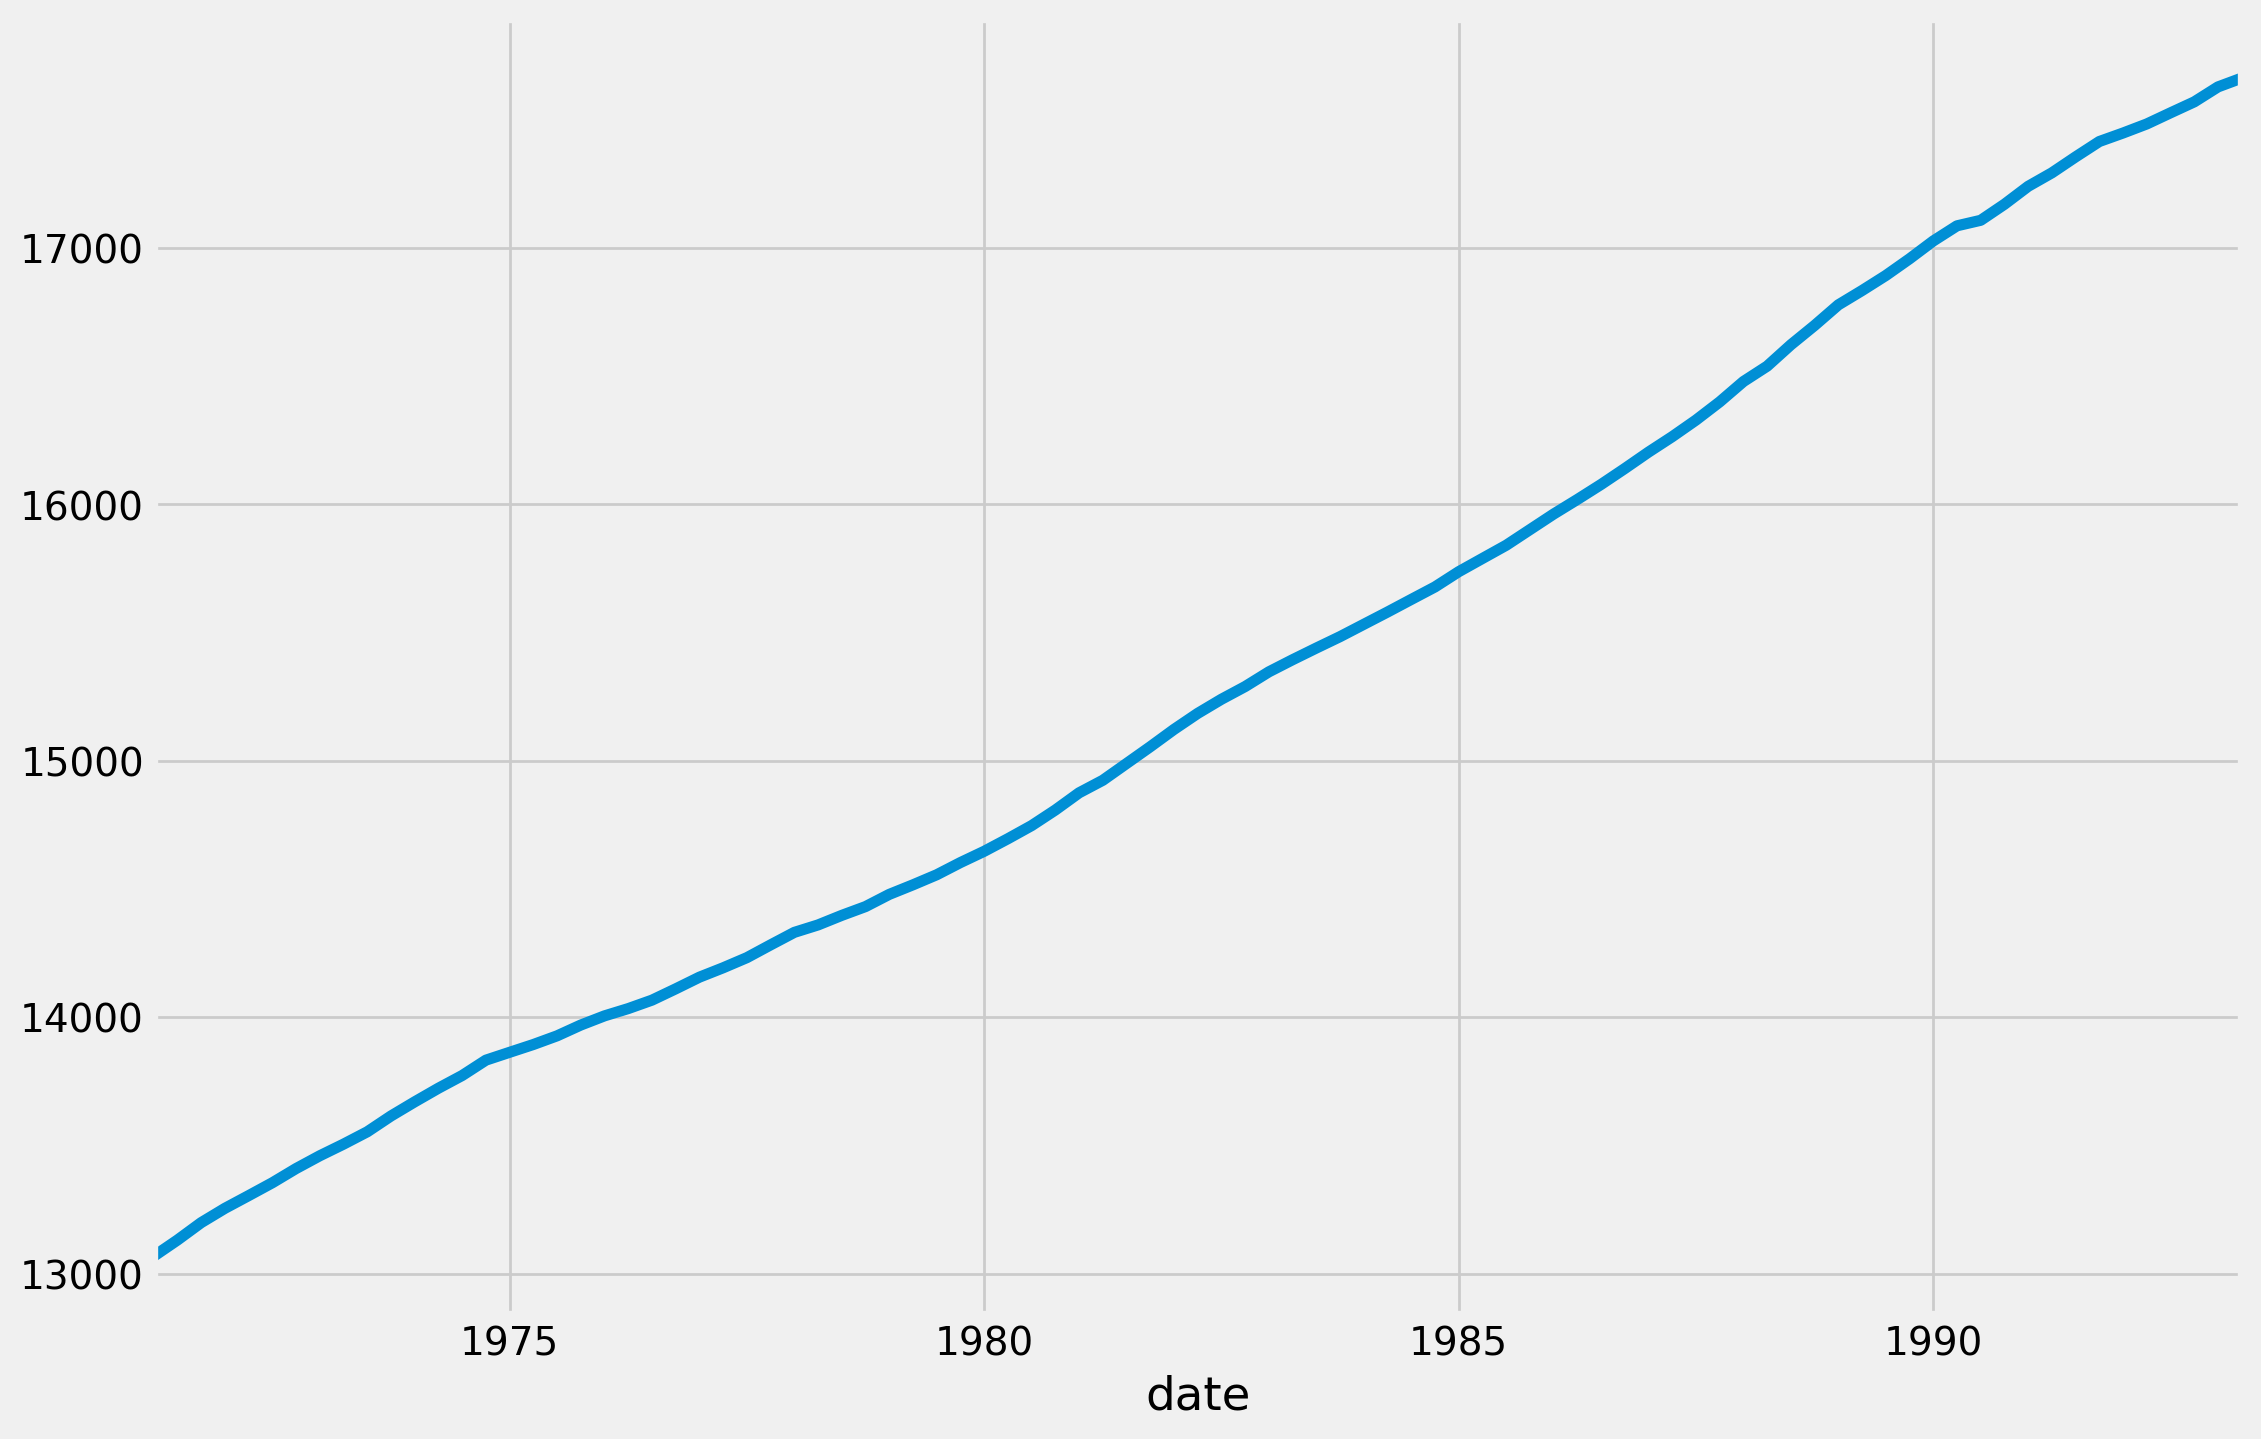

In [6]:
# YOUR CODE HERE
df['residents'].plot(figsize=(12,8))

## Part 2 - Seasonal Decomposition

A time series can be split into three components: **trend**, **seasonal**, and **residual**.

### 4. Decompose `residents` using `seasonal_decompose` (`period=4` since this is quarterly data). Plot the trend, seasonal, and residual components.

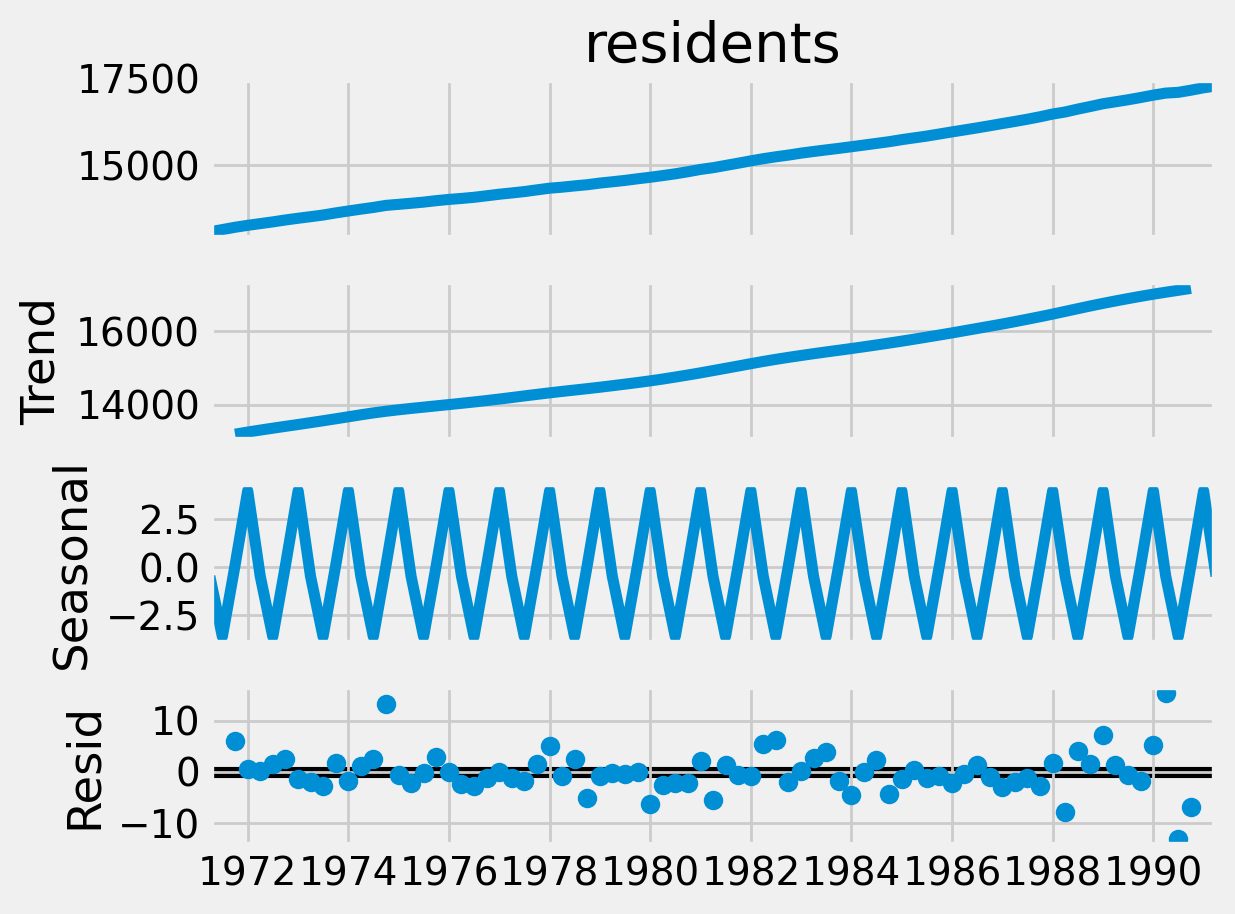

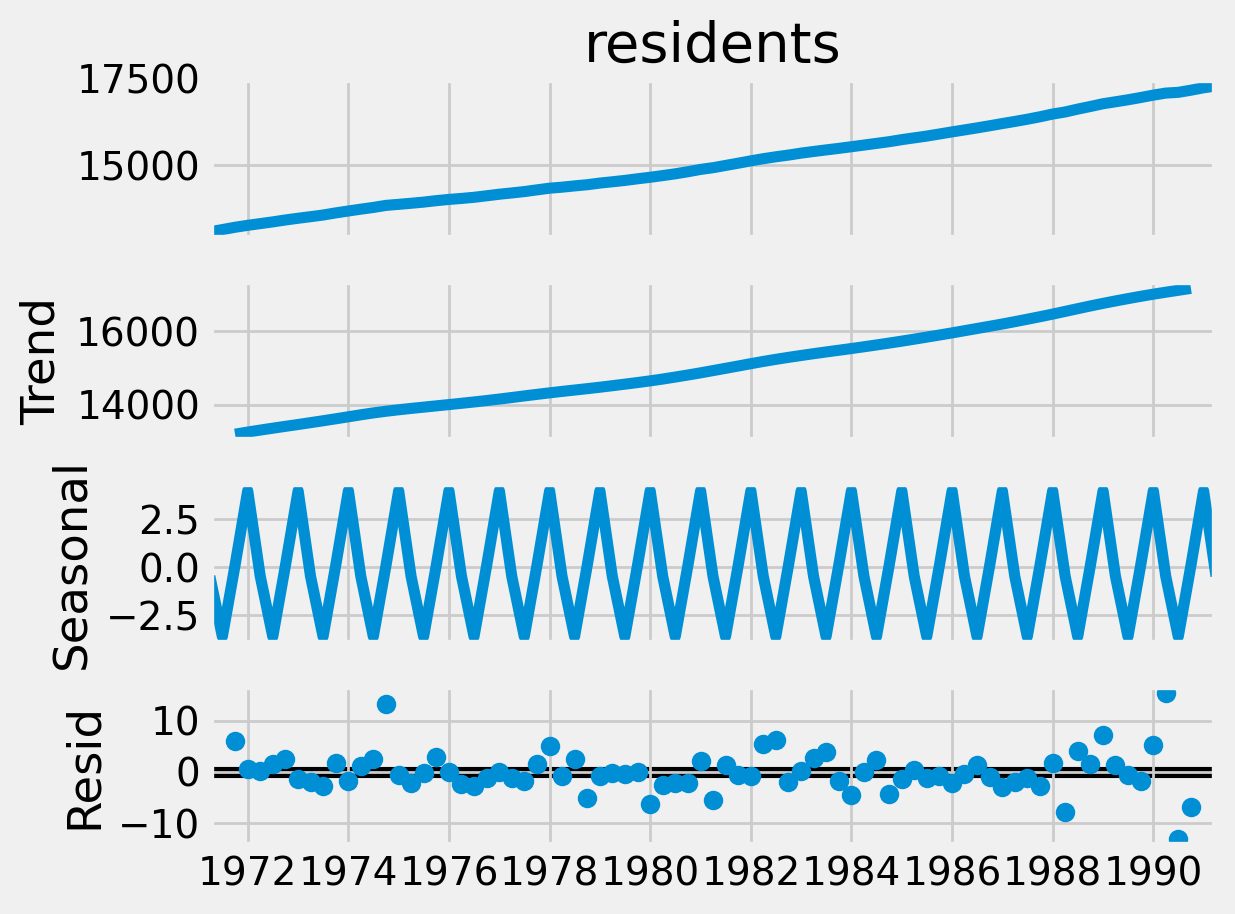

In [7]:
# YOUR CODE HERE

dcom = seasonal_decompose(df_eda['residents'], period=4)
dcom.plot()

## Part 3 - Visualizing Trend with Rolling Mean and Resampling.

With quarterly data, a 4-quarter (1-year) rolling window is the suitable choice, as it averages away any seasonal fluctuations and leaves just the trend.

### 5. Compute and plot a 4-quarter rolling mean of `residents`, overlaid on the raw series.

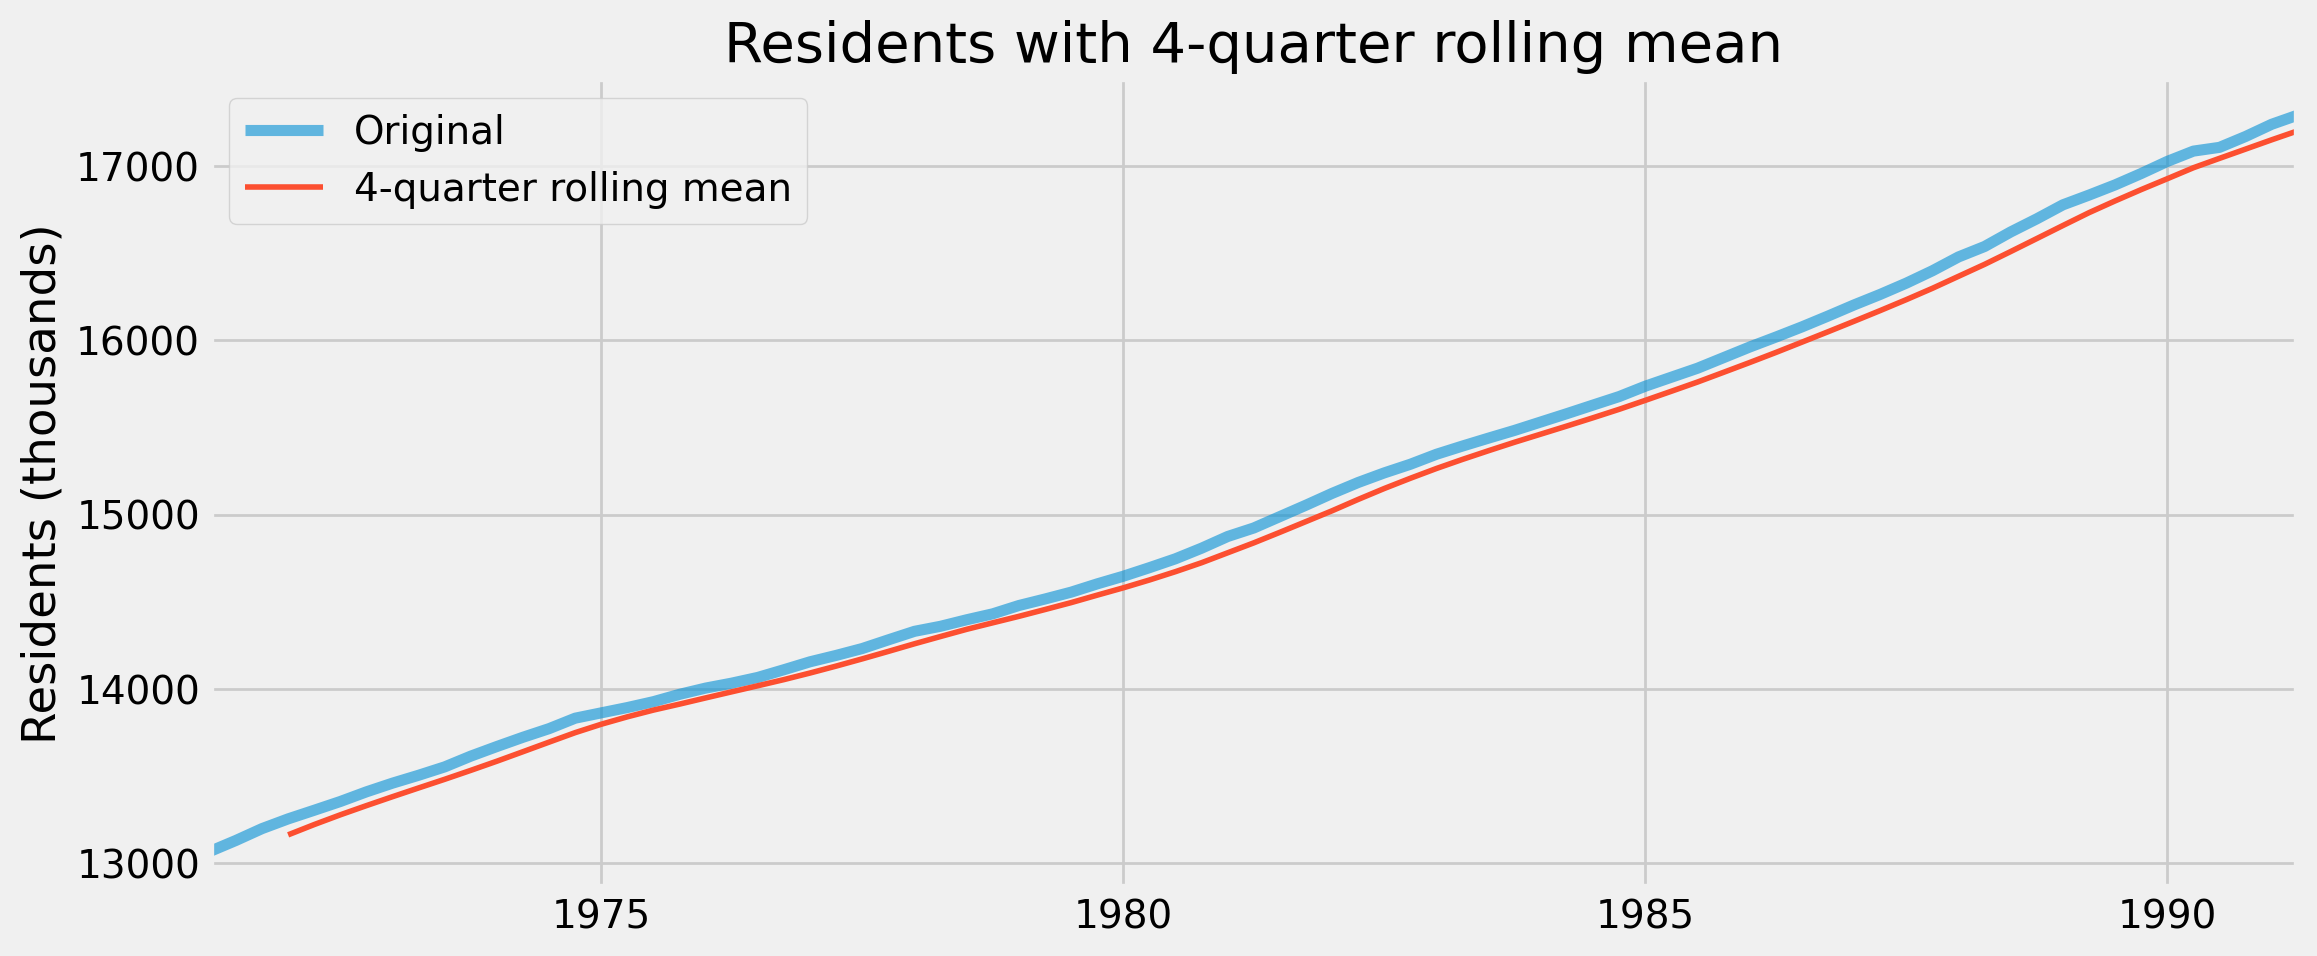

In [8]:
# YOUR CODE HERE
rmean = df_eda['residents'].rolling(window=4).mean()

ax = df_eda['residents'].plot(figsize=(12, 5), label='Original', alpha=0.6)
rmean.plot(ax=ax, label='4-quarter rolling mean', linewidth=2)
plt.title('Residents with 4-quarter rolling mean')
plt.ylabel('Residents (thousands)')
plt.xlabel('')
plt.legend()
plt.show()

### 6. Plot a 4-quarter rolling standard deviation. Is the spread of fluctuations roughly stable over time, or does it change?

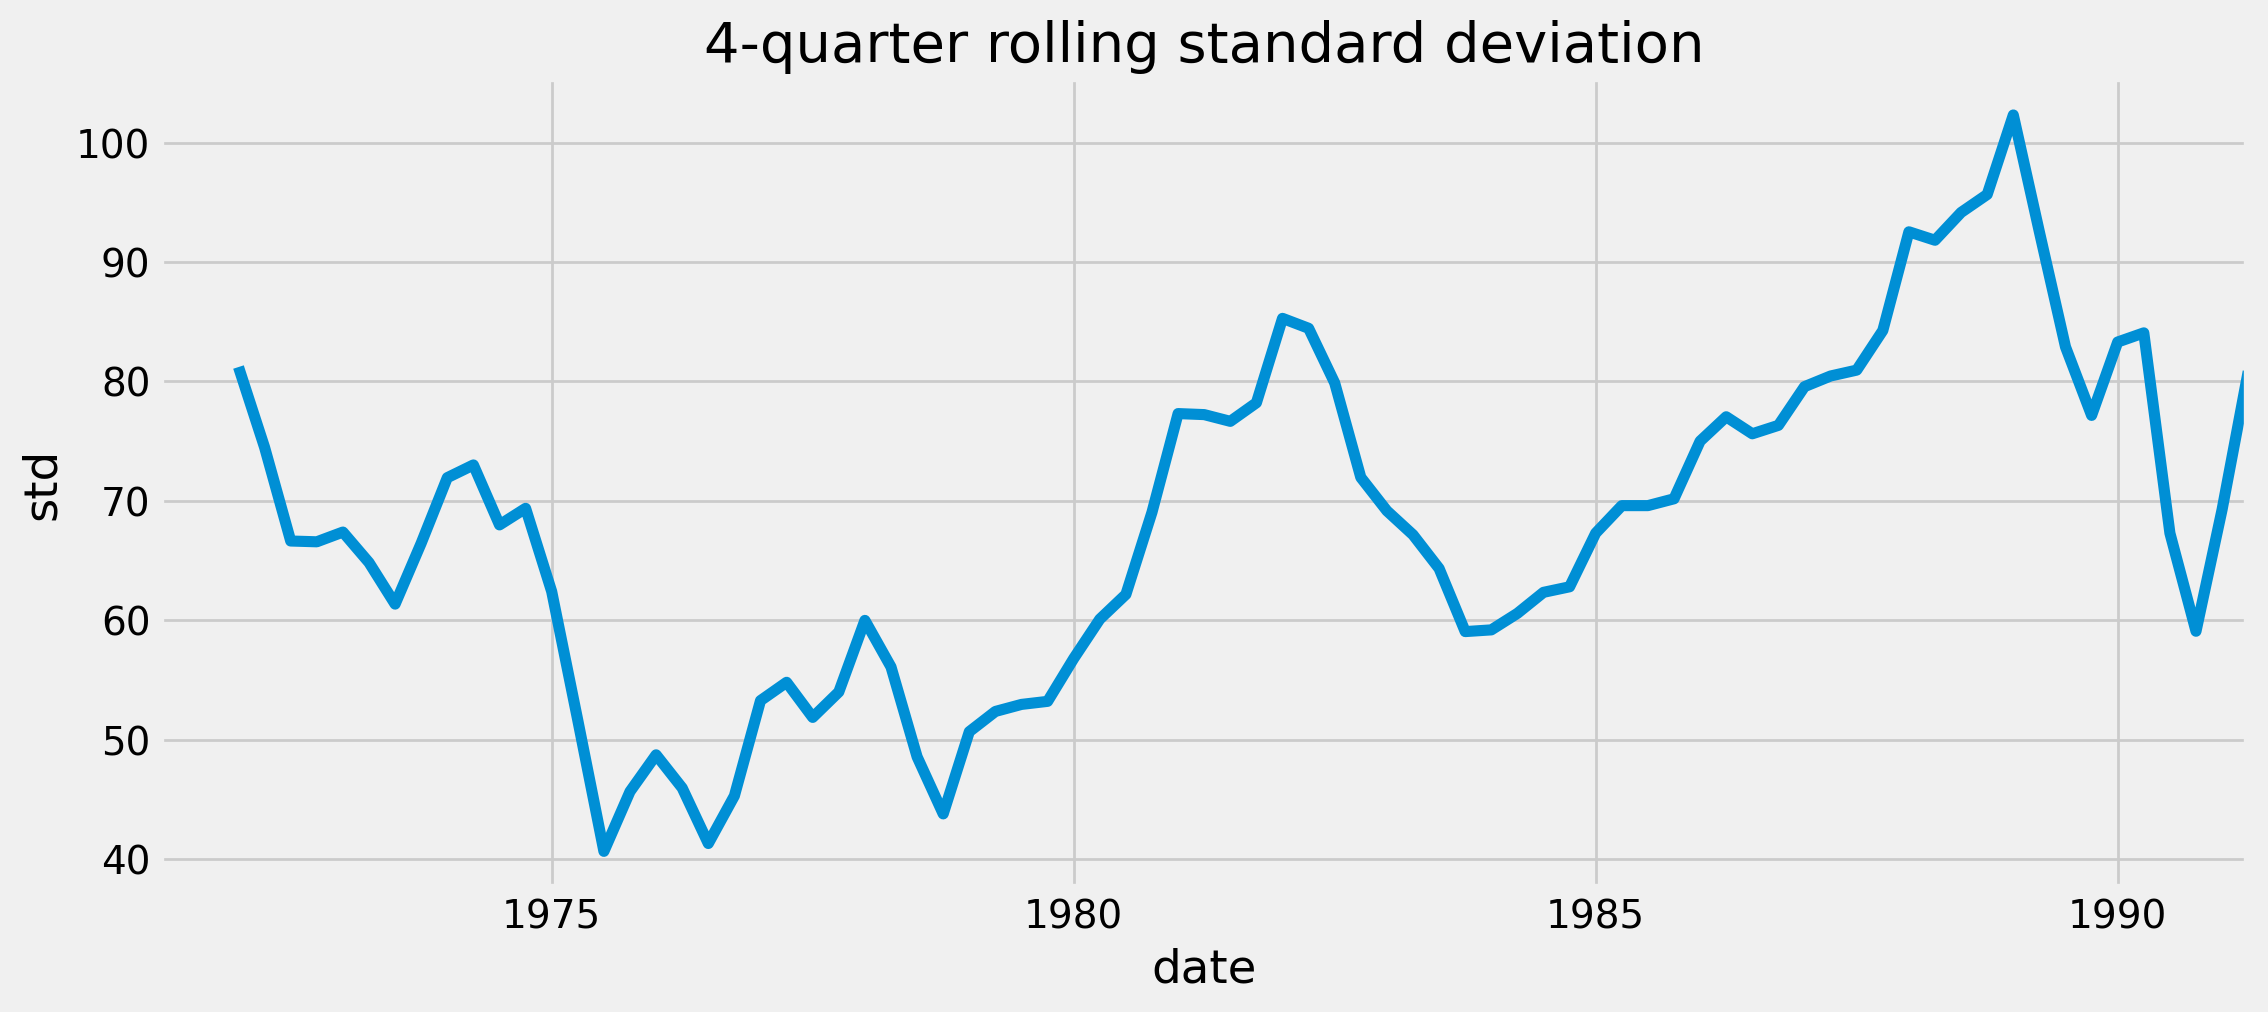

In [10]:
# YOUR CODE HERE
rstd = df_eda['residents'].rolling(window=4).std()

rstd.plot(figsize=(12, 5))
plt.title('4-quarter rolling standard deviation')
plt.ylabel('std')
plt.show()

## Part 4 - Stationarity and the ADF Test

A stationary series has a constant mean, variance, and autocorrelation structure over time *(most classical forecasting models assume this)*. We test for it with the **Augmented Dickey-Fuller (ADF) test**:

- **Null hypothesis (H0):** the series has a unit root (i.e. it is *non-stationary*).
- If the p-value is small (typically ≤ 0.05), we reject H0 and conclude the series **is** *stationary*.

### 7. Write an `adf_test()` helper function that runs `adfuller()` and prints the test statistic, p-value, and a plain-English conclusion.

In [11]:
def adf_test(series,title=''):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna(),autolag='AIC') # .dropna() handles differenced data
    
    labels = ['ADF test statistic','p-value','# lags used','# observations']
    out = pd.Series(result[0:4],index=labels)

    for key,val in result[4].items():
        out[f'critical value ({key})']=val
        
    print(out.to_string())          # .to_string() removes the line "dtype: float64"
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")

### 8. Run `adf_test()` on the raw `residents` series. Then apply `.diff()` and run it again. Is one difference enough?

In [12]:
# YOUR CODE HERE
adf_test(df_eda['residents'])

Augmented Dickey-Fuller Test: 
ADF test statistic       1.810417
p-value                  0.998369
# lags used              6.000000
# observations          74.000000
critical value (1%)     -3.521980
critical value (5%)     -2.901470
critical value (10%)    -2.588072
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


### 9. If the first difference wasn't enough, try a second difference (`.diff().diff()`). Is it stationary now? 
*This will be your `d` term in the modeling stage*.

In [14]:
# YOUR CODE HERE
adf_test(df_eda['residents'].diff().diff())

Augmented Dickey-Fuller Test: 
ADF test statistic      -3.148284
p-value                  0.023180
# lags used              4.000000
# observations          74.000000
critical value (1%)     -3.521980
critical value (5%)     -2.901470
critical value (10%)    -2.588072
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


## Part 5 - Autocorrelation and Seasonality

ACF and PACF plots show how correlated a series is with its own past values at different lags. We look at these on the **differenced** series, with the trend removed, any repeating seasonal correlation stands out clearly instead of being buried under the trend's slow decay.

### 10. Plot the ACF and PACF of the series out to at least 20 lags.

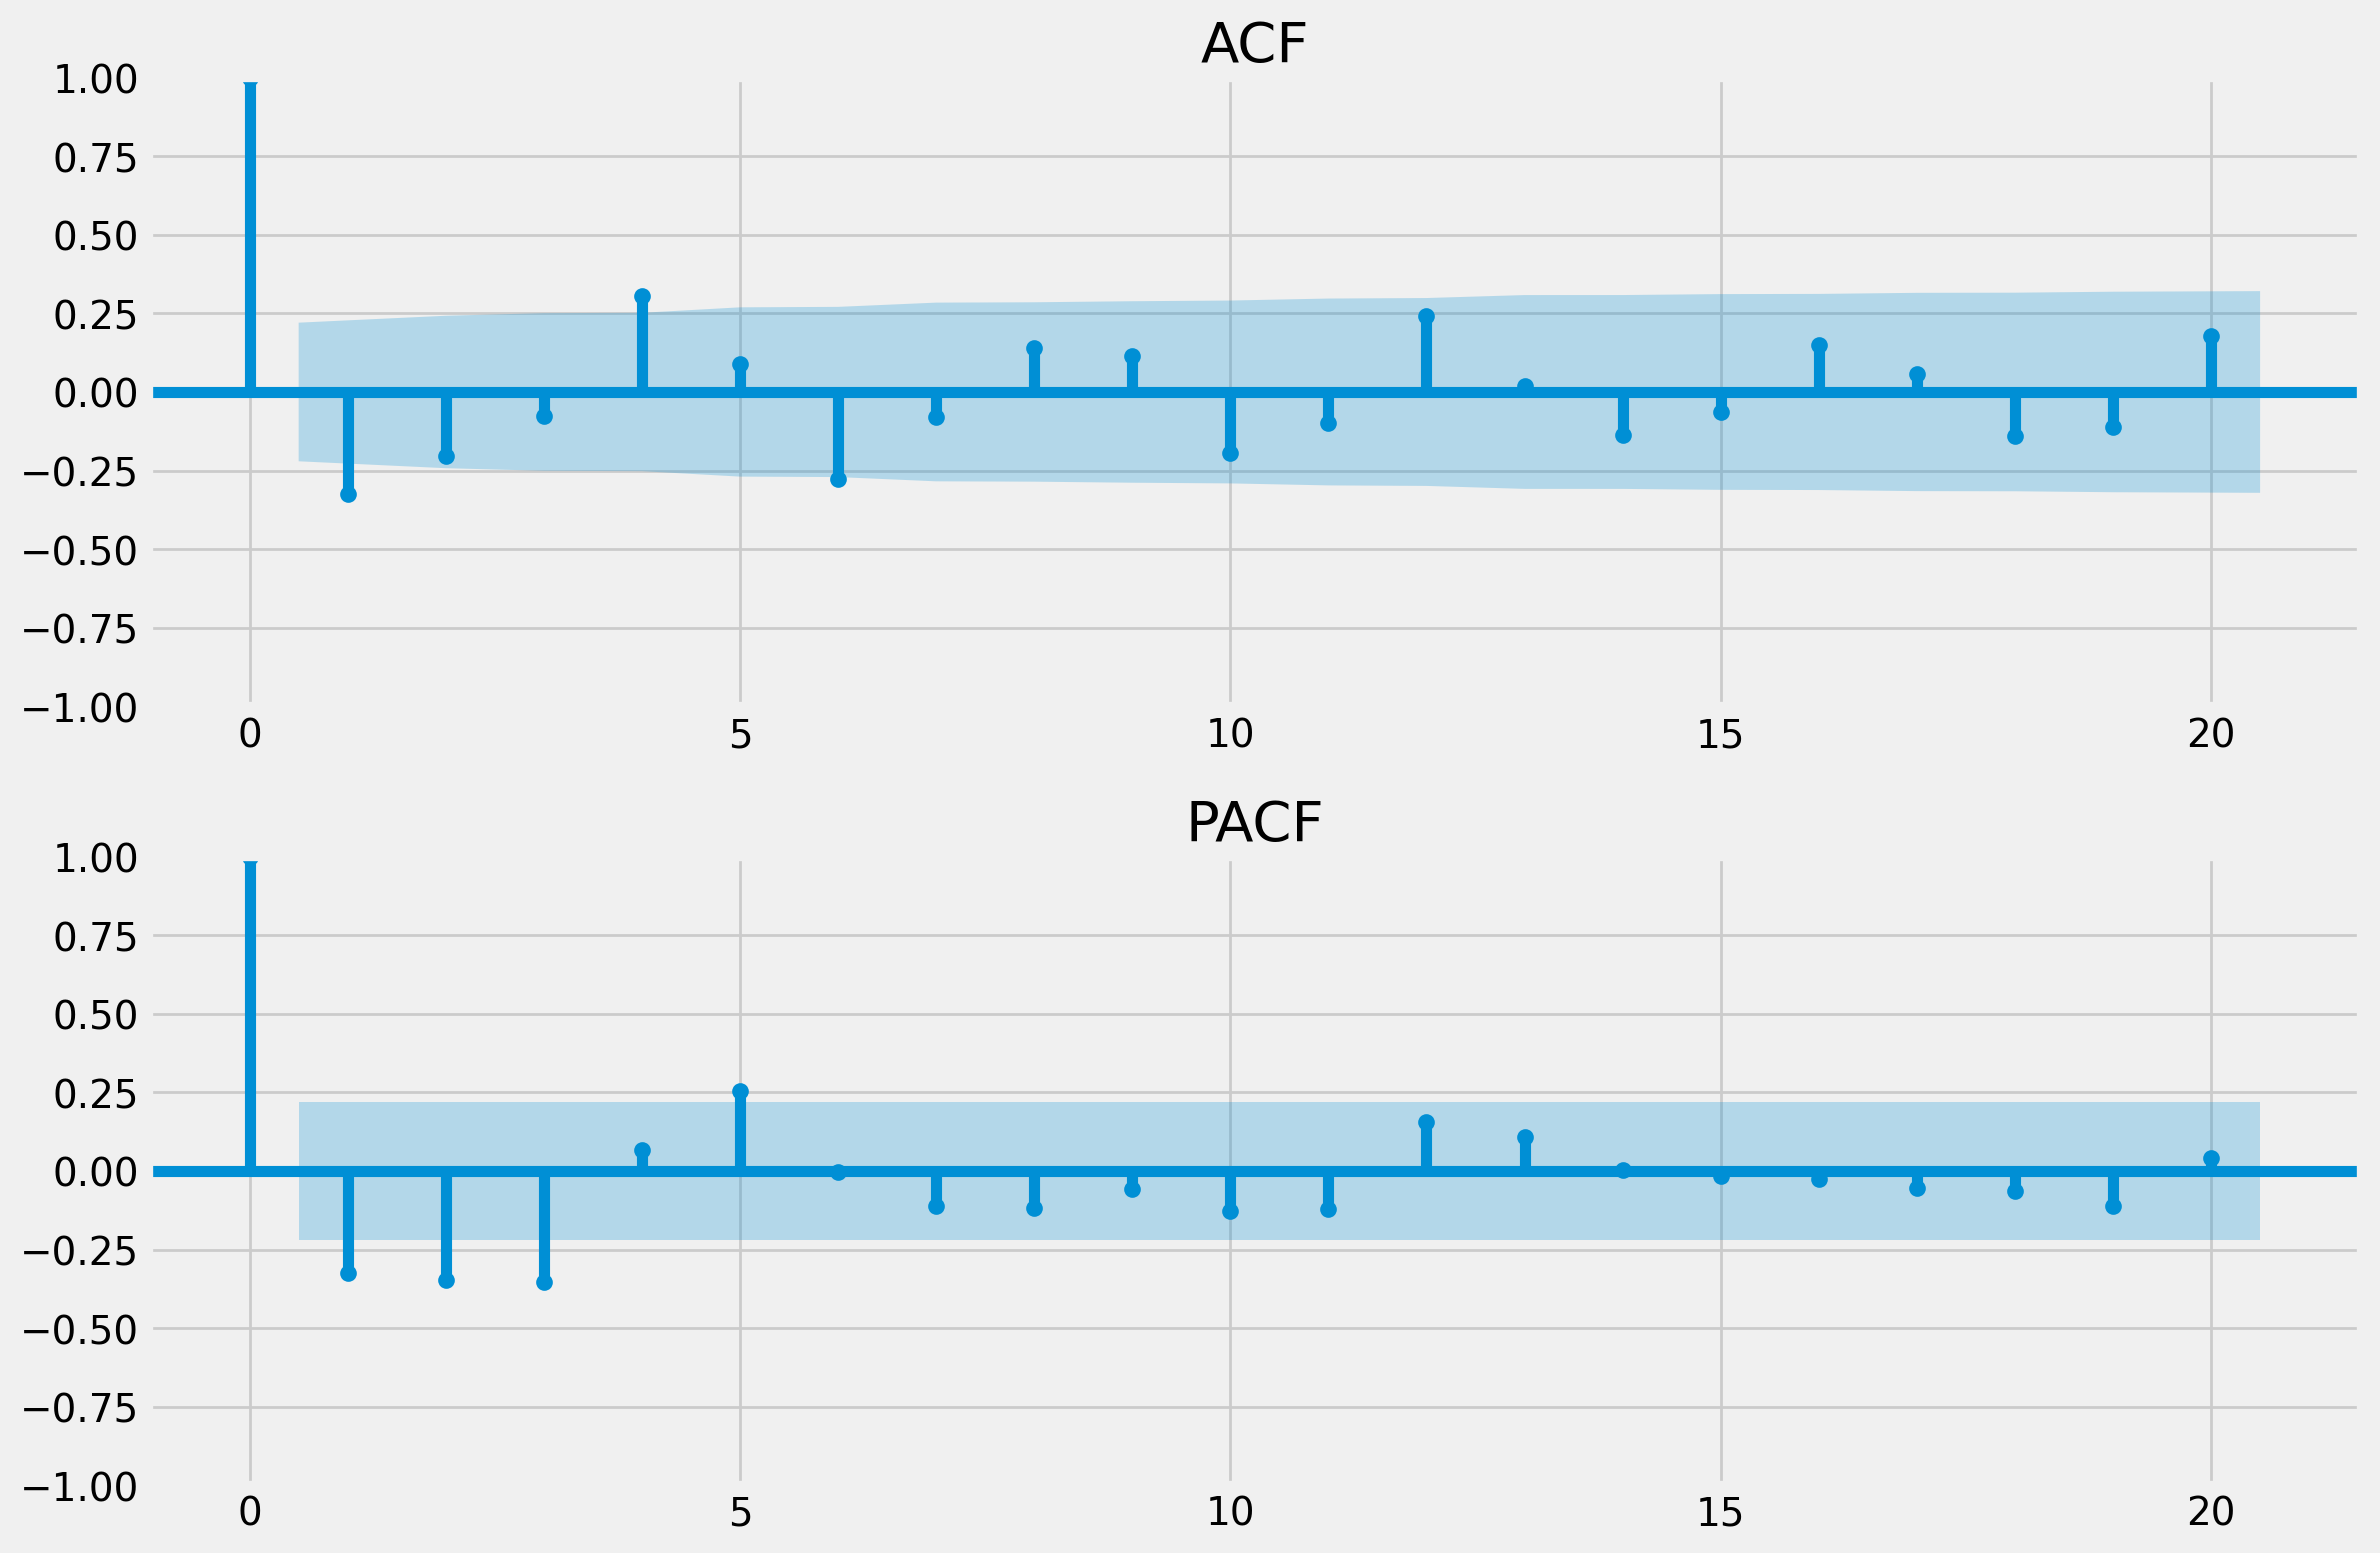

In [15]:
# YOUR CODE HERE
rdiff = df_eda['residents'].diff().diff().dropna()

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(rdiff, lags=20, ax=ax[0])
ax[0].set_title('ACF')

plot_pacf(rdiff, lags=20, ax=ax[1])
ax[1].set_title('PACF')

plt.tight_layout()
plt.show()

### 11. Look closely at the ACF plot. At which lag do you see the strongest spike? What does that tell you about the data?

At lag 4, the ACF spike sticks out above the shaded band.

That means values 4 time steps apart tend to move together, suggesting a repeating pattern every 4 periods (like seasonality), not just random noise.